---This is the basic information about application_train file:---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


['SK_ID_CURR', 'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_CONTRACT_TYPE', 'FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'OCCUPATION_TYPE', 'CNT_CHILDREN', 'TARGET']/n


(307511, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SK_ID_CURR           307511 non-null  int64  
 1   CODE_GENDER          307511 non-null  object 
 2   DAYS_BIRTH           307511 non-null  int64

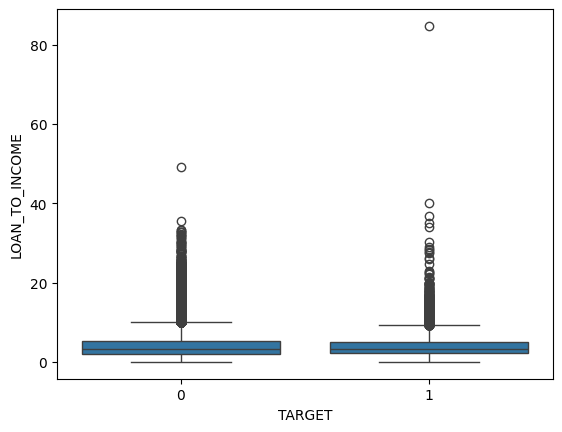

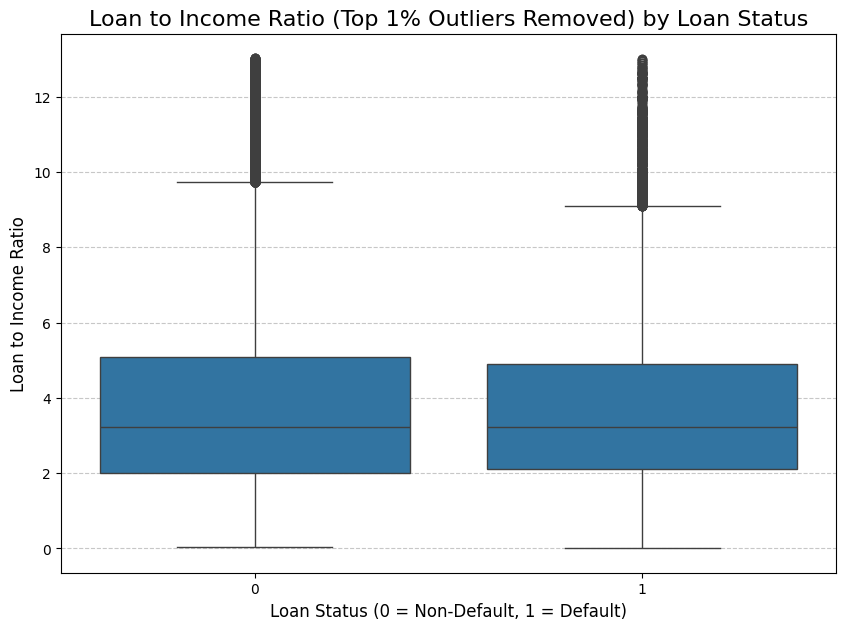

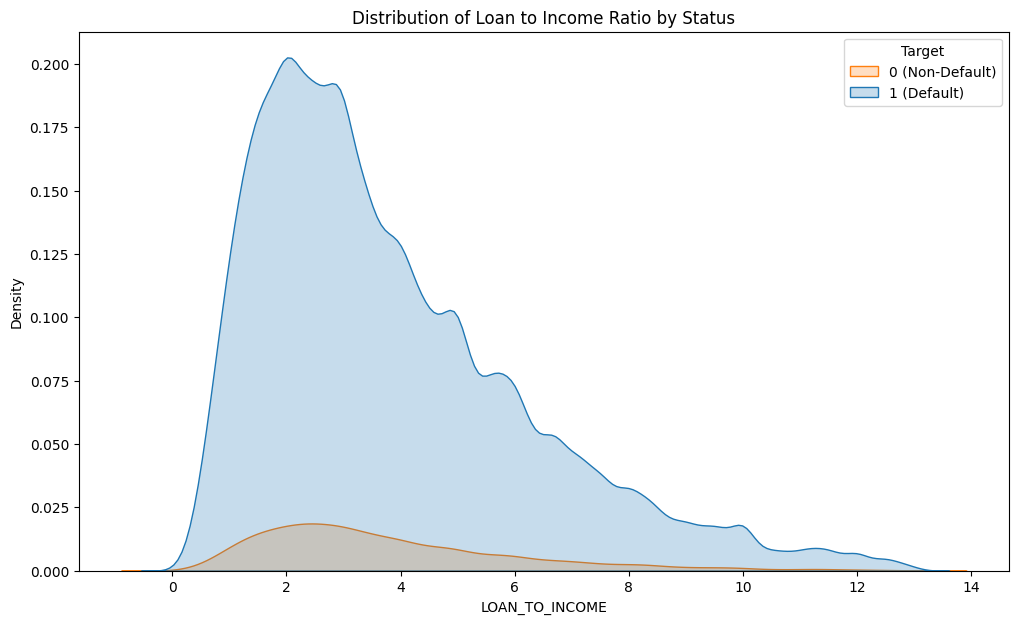

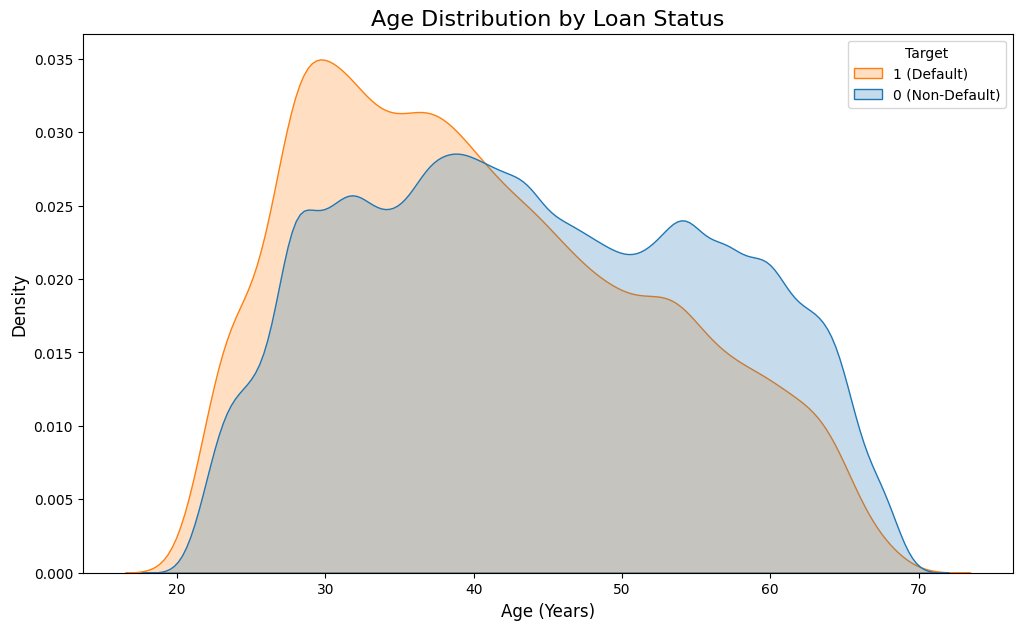

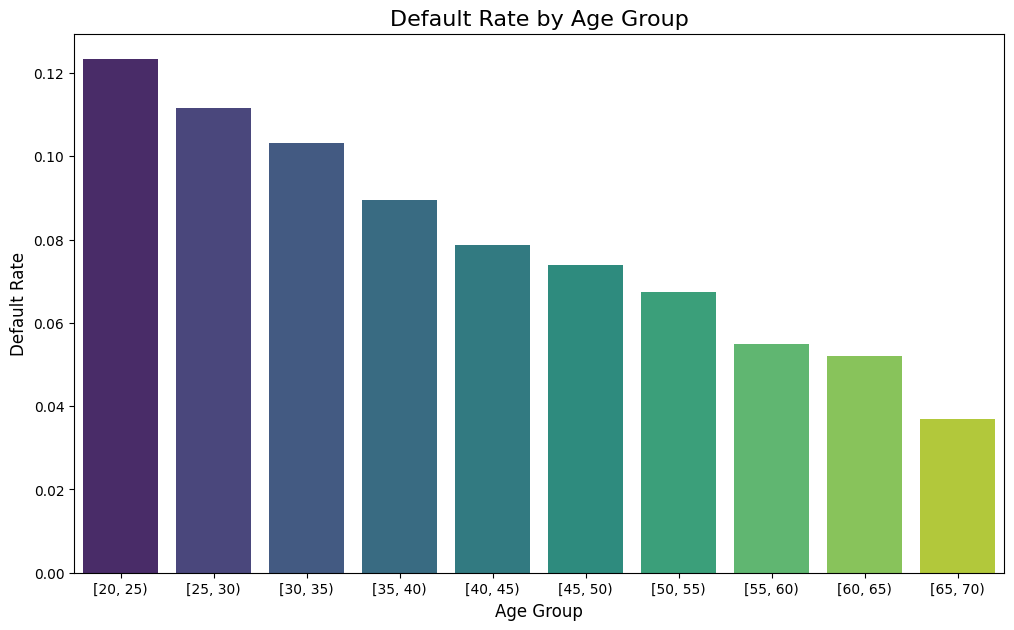

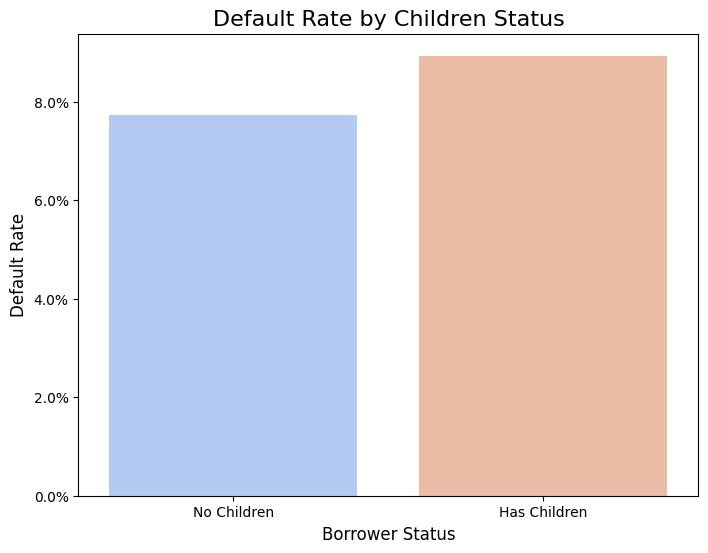

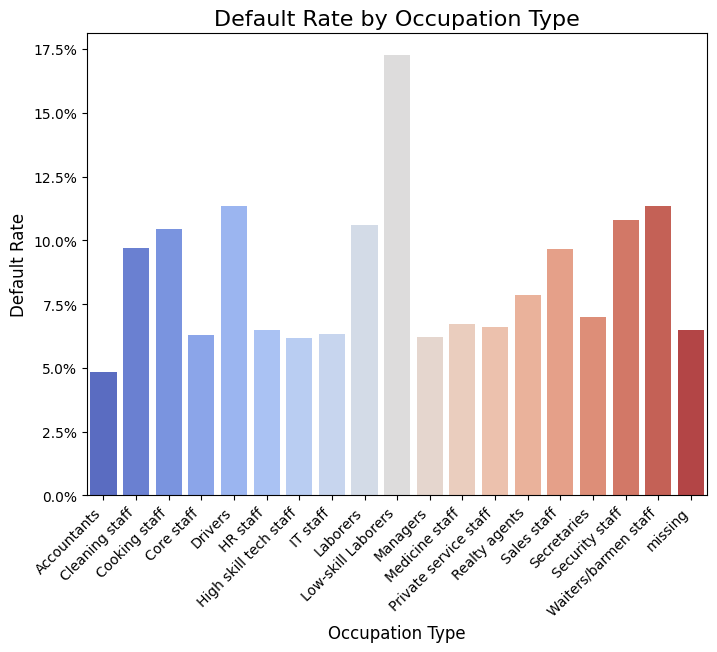

--- Most Positively Correlated Features with DEFAULT ---
TARGET                  1.000000
DAYS_BIRTH              0.079033
YEARS_EMPLOYED          0.045725
EMPLOYMENT_STABILITY    0.042997
HAS_CHILDREN            0.020387
CNT_CHILDREN            0.019409
ANNUITY_TO_INCOME       0.016143
ANNUITY_TO_LOAN         0.012398
CNT_FAM_MEMBERS         0.009695
FLAG_MOBIL              0.000538
HAS_PHONE               0.000538
HAS_EMAIL              -0.001827
FLAG_EMAIL             -0.001827
SK_ID_CURR             -0.002011
AMT_INCOME_TOTAL       -0.004086
Name: TARGET, dtype: float64


--- Most Negatively Correlated Features with DEFAULT ---
ANNUITY_TO_INCOME    0.016143
ANNUITY_TO_LOAN      0.012398
CNT_FAM_MEMBERS      0.009695
FLAG_MOBIL           0.000538
HAS_PHONE            0.000538
HAS_EMAIL           -0.001827
FLAG_EMAIL          -0.001827
SK_ID_CURR          -0.002011
AMT_INCOME_TOTAL    -0.004086
LOAN_TO_INCOME      -0.007713
AMT_ANNUITY         -0.012499
AMT_CREDIT          -0.030230


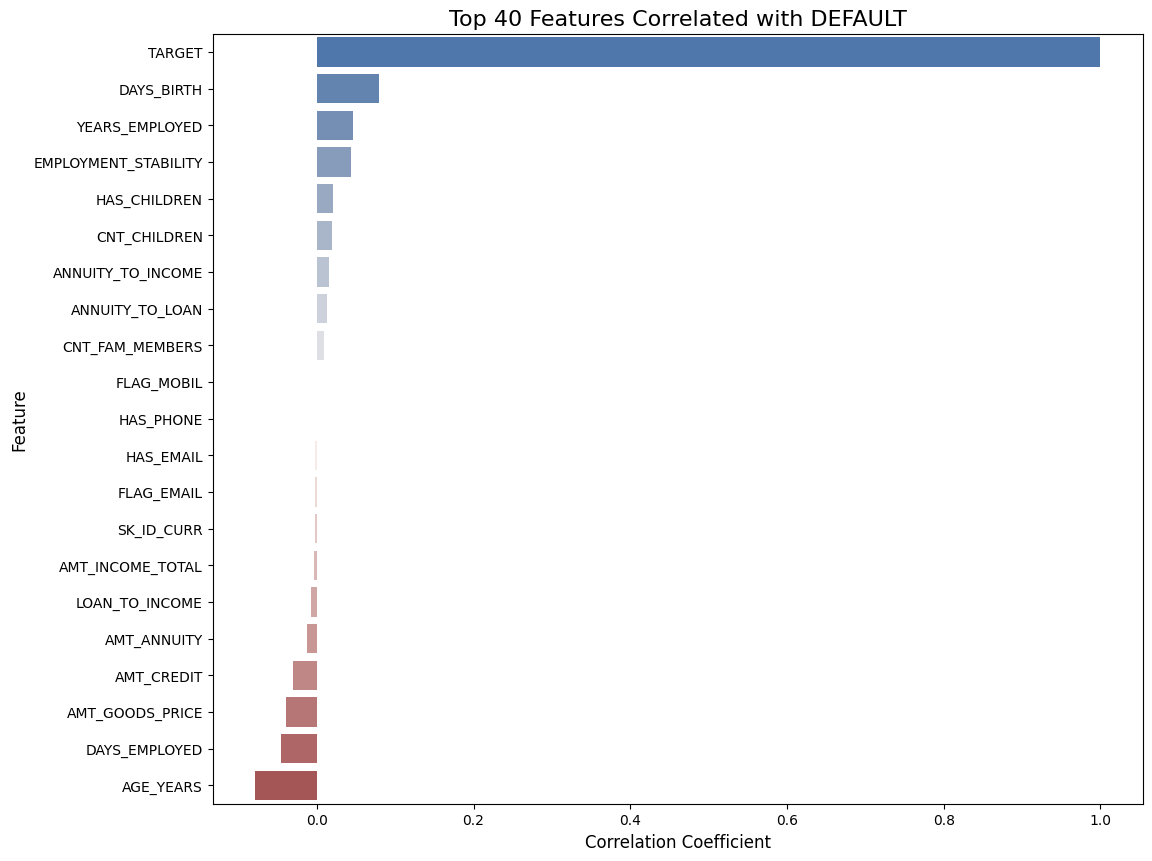

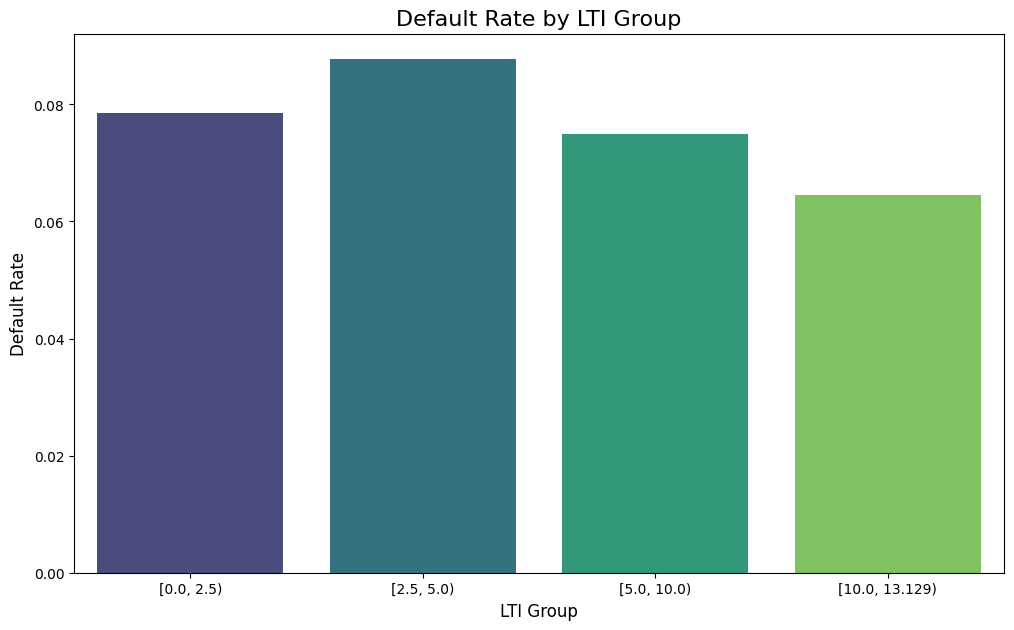

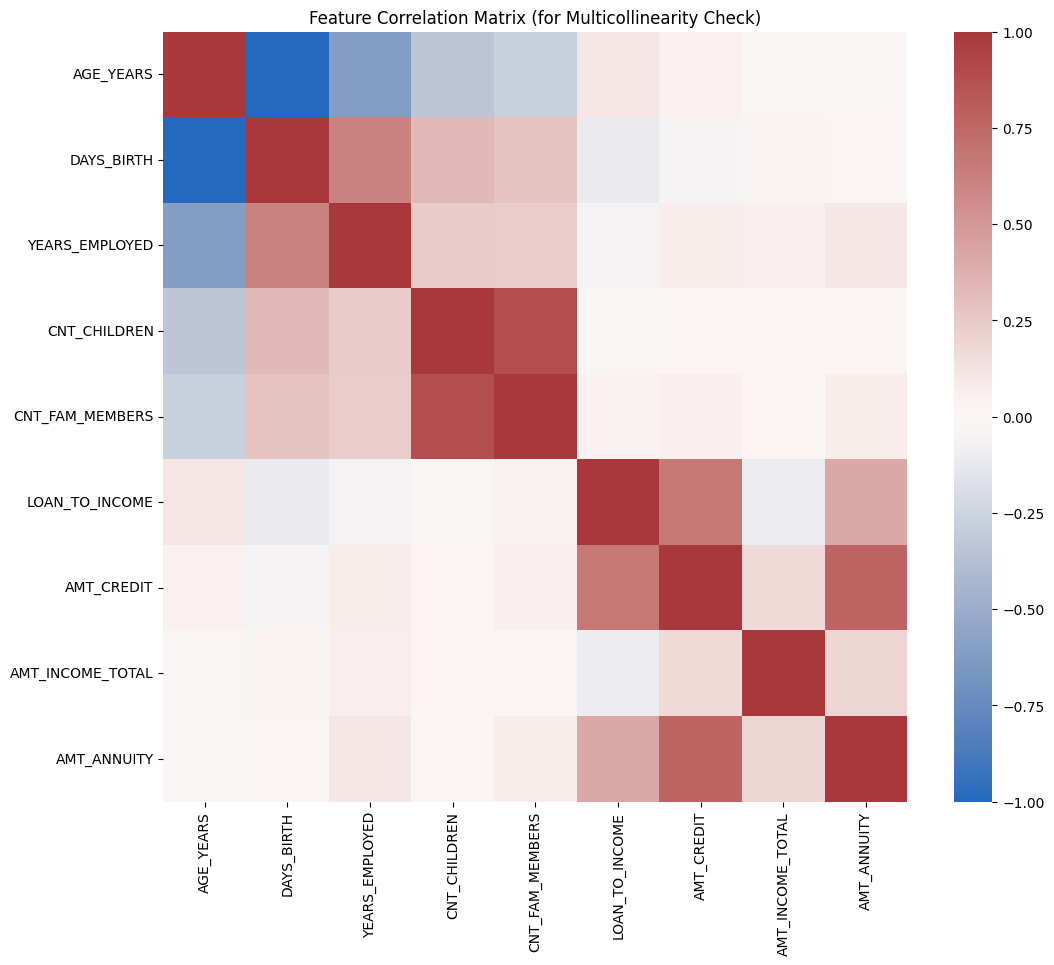

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns


# 1. Locate all input files
ip = r"C:\Users\Christina\Dropbox\BUSINESS\Pet Care\1. LEADERSHIP\Reference & Learning\Fintech\Credit Risk Project\home-credit-default-risk-Kaggle\installments_payments.csv"
at = r"C:\Users\Christina\Dropbox\BUSINESS\Pet Care\1. LEADERSHIP\Reference & Learning\Fintech\Credit Risk Project\home-credit-default-risk-Kaggle\application_train.csv"

# 2. Read from the input files and convert them to dataframes
installments_payments = pd.read_csv(ip)
application_train = pd.read_csv(at)


print("---This is the basic information about application_train file:---")
application_train.info()
print("\n")

# 3. Make dataframe from only the required columns. Convert 122 columns from the original file to the required 20 columns
# These denote Applicant Demographics & Stability
req_cols1_AT = ['SK_ID_CURR', 'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_FAM_MEMBERS']
# These denote Income & Loan Structure
req_cols2_AT = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_CONTRACT_TYPE']
# These denote Housing & Residence
req_cols3_AT = ['NAME_HOUSING_TYPE', 'DAYS_REGISTRATION', 'DAYS_RES_PUB', 'REGION_POPULATION_RELATIVE']
# These denote Contactability & Documentation
req_cols3_AT = ['FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'OCCUPATION_TYPE', 'CNT_CHILDREN']
# These denote Target Variable (1 = defaulted, 0 = repaid (label for training)
req_cols4_AT = ['TARGET']
req_cols_AT = req_cols1_AT + req_cols2_AT + req_cols3_AT + req_cols4_AT

print(f"{req_cols_AT}/n")
print("\n")

# Get the desired dataframe
AT = application_train[req_cols_AT]

print(f"{AT.shape}\n") # to do: make this give output as these many rows and these many columns.
print(f"{AT.info()}\n")

# 4. Calculate percentage of missing values per column
missing_percentage = AT.isnull().sum() / len(AT) * 100

# 4.1 Convert the series to a DataFrame and reset the index
missing_df = missing_percentage.reset_index()
missing_df.columns = ['Column Name', 'Missing Percentage']

# 4.2 Show the columns with largest missing values first
missing_df_sorted = missing_df.sort_values(by = 'Missing Percentage', ascending = False)

# 4.3 Show only the columns which have missing data, ignore columns with missing values percentage equal TO ZERO)
columns_with_missing_values = missing_df_sorted[missing_df_sorted['Missing Percentage'] > 0]

print(f"{columns_with_missing_values}\n")
print(f"{AT['OCCUPATION_TYPE'].value_counts()}\n")

# 5. Operate on the missing value columns and make the data more useable
# 5.1 For the three columns which have only 0.1% of the data missing, the rows can be straightaway deleted
AT1 = AT.dropna(subset=['AMT_GOODS_PRICE', 'AMT_ANNUITY','CNT_FAM_MEMBERS'])
num_rows_AT1 = len(AT1)
num_rows_AT = len(AT)
print(f"The operation removed rows and {num_rows_AT1/num_rows_AT*100:.2f}% of rows are still there\n")

# The column OCCUPATION_TYPE has 31% missing values which is a large chunk. We will give them value as 'missing'
AT1.loc[AT1['OCCUPATION_TYPE'].isnull(), 'OCCUPATION_TYPE'] = 'missing'
AT = AT1
print(f"{AT1['OCCUPATION_TYPE'].value_counts()}\n")

# Can delete this section, created for medium article
print(f"{AT1.shape}\n") # to do: make this give output as these many rows and these many columns.
print(f"{AT1.describe(include = 'all')}\n")
print(f"{AT1.info()}\n")
print(f"{AT1.nunique()}\n")

# Create numerical features (ratios) which will help determine credit profile
print(f"{AT1.columns}\n")
print(f"{AT1.head(5)}\n")

AT1['AGE_YEARS'] = -1* AT1['DAYS_BIRTH'] / 365
AT1['YEARS_EMPLOYED'] = -1* AT1['DAYS_EMPLOYED'] / 365
AT1['LOAN_TO_INCOME'] = AT1['AMT_CREDIT'] / AT1['AMT_INCOME_TOTAL']
AT1['ANNUITY_TO_INCOME'] = AT1['AMT_ANNUITY'] / AT1['AMT_INCOME_TOTAL']
AT1['ANNUITY_TO_LOAN'] = AT1['AMT_ANNUITY'] / AT1['AMT_CREDIT']
AT1['EMPLOYMENT_STABILITY'] = AT1['YEARS_EMPLOYED'] / AT1['AGE_YEARS']

# Create binary flag features
AT1['HAS_CAR'] = AT1['FLAG_OWN_CAR']
AT1['HAS_PROPERTY'] = AT1['FLAG_OWN_REALTY']
AT1['HAS_PHONE'] = AT1['FLAG_MOBIL']
AT1['HAS_EMAIL'] = AT1['FLAG_EMAIL']
AT1['HAS_CHILDREN'] = np.where(AT1['CNT_CHILDREN'] > 0, 1, 0)

print(f"{AT1.columns}\n")
print(f"{AT1.head(5)}\n")
print(f"{AT1.value_counts()}\n")


# -----Begin Exploratory Data Analysis-----

# --LOAN TO INCOME vs. TARGET (DEFAULT)--

# Understand data - how manny percentage of borrowers default (TARGET =1)
AT['TARGET'].value_counts(normalize=True)

# Plot relationship between TARGET and LOAN_TO_INCOME data
sns.boxplot(x='TARGET', y='LOAN_TO_INCOME', data=AT1)
# Output is a highly skewed graph which doesn't make any sense

AT1['LOAN_TO_INCOME'].describe()
# Describe reveals a highly skewed data with one value showing L/I as 85 which is unreal. 75% of data is ~5

limit = AT1['LOAN_TO_INCOME'].quantile(0.99)
print(f"The 99th percentile is: {limit:.2f}")

# 99% of the borrowers have a ratio of 13.03 or less. 
# Top 1%" of the data is spread out over a large range, from 13.03 all the way up to 84.74!
# We will ignore this outlier data to get a more understandable plot

# Create the Feature Engineered dataset
AT1_FE = AT1[AT1['LOAN_TO_INCOME'] < limit].copy()


# Create chart using filtered non-outlier data
plt.figure(figsize=(10, 7))
sns.boxplot(x = 'TARGET', y ='LOAN_TO_INCOME', data = AT1_FE)

plt.title(f'Loan to Income Ratio (Top 1% Outliers Removed) by Loan Status', fontsize=16)
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)', fontsize=12)
plt.ylabel('Loan to Income Ratio', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#Create the KDE plot mapping Loan to Income vs. Target
plt.figure(figsize=(12, 7))
sns.kdeplot(data = AT1_FE, x='LOAN_TO_INCOME', hue='TARGET', fill=True)
plt.title('Distribution of Loan to Income Ratio by Status')
plt.legend(title='Target', labels=['0 (Non-Default)', '1 (Default)'])
plt.show()

# --AGE_YEARS vs. TARGET (DEFAULT)--
AT1_FE['AGE_YEARS'].describe()

plt.figure(figsize=(12, 7))

# Create the KDE plot, separating by the TARGET variable
sns.kdeplot(data=AT1_FE, x='AGE_YEARS', hue='TARGET', fill=True, common_norm=False)

plt.title('Age Distribution by Loan Status', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.legend(title='Target', labels=['1 (Default)', '0 (Non-Default)'])

# Create binned bar chart
# 1. Create age bins
# We use pd.cut to segment the age data into groups.
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
AT1_FE['AGE_BINS'] = pd.cut(AT1_FE['AGE_YEARS'], bins=age_bins, right=False)

# 2. Calculate the default rate for each age bin
# We group by the new bins and calculate the mean of 'TARGET'.
# The mean of a 0/1 column IS the percentage of 1s (the default rate).
age_risk = AT1_FE.groupby('AGE_BINS', observed=True)['TARGET'].mean().reset_index()

# 3. Create the bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='AGE_BINS', y='TARGET', data=age_risk, hue='AGE_BINS', palette='viridis', legend=False)

# 4. Add titles and format the y-axis as a percentage for clarity
plt.title('Default Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)

# --HAS_CHILDREN vs. TARGET (DEFAULT)--
# 1. Group the data by 'HAS_CHILDREN' and calculate the default rate
# The .mean() of a 0/1 column gives the percentage of 1s (the default rate)
children_risk = AT1_FE.groupby('HAS_CHILDREN')['TARGET'].mean().reset_index()

# Optional: To make the chart labels clearer, you can map the 0/1 to text
children_risk['HAS_CHILDREN_LABEL'] = children_risk['HAS_CHILDREN'].map({0: 'No Children', 1: 'Has Children'})

# 2. Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='HAS_CHILDREN_LABEL', y='TARGET', data=children_risk, hue='HAS_CHILDREN_LABEL', palette='coolwarm', legend=False)
# 3. Add clear, correct titles and labels
plt.title('Default Rate by Children Status', fontsize=16)
plt.xlabel('Borrower Status', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)

# 4. Format the y-axis to show percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

# --OCCUPATION_TYPE vs. TARGET (DEFAULT)--
# 1. Group the data by 'OCCUPATION_TYPE' and calculate the default rate
# The .mean() of a 0/1 column gives the percentage of 1s (the default rate)
occupation_groups = AT1_FE.groupby('OCCUPATION_TYPE')['TARGET'].mean().reset_index()
occupation_groups_in_chart = occupation_groups['OCCUPATION_TYPE']

# 2. Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=occupation_groups_in_chart, y='TARGET', data=occupation_groups, hue=occupation_groups_in_chart, palette='coolwarm', legend=False)
plt.xticks(rotation=45, ha='right')
# 3. Add clear, correct titles and labels
plt.title('Default Rate by Occupation Type', fontsize=16)
plt.xlabel('Occupation Type', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)

# 4. Format the y-axis to show percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

# Calculate the full correlation matrix for numerical columns only
correlation_matrix = AT1_FE.corr(numeric_only=True)

# Select only the 'TARGET' column and sort the values
target_correlation = correlation_matrix['TARGET'].sort_values(ascending=False)

# Print the top 15 and bottom 15 correlations
print("--- Most Positively Correlated Features with DEFAULT ---")
print(target_correlation.head(15))
print("\n" + "="*50 + "\n")
print("--- Most Negatively Correlated Features with DEFAULT ---")
print(target_correlation.tail(15))

# We'll plot the top N most correlated features (excluding TARGET itself)
top_n = 20
# Select the top N positive and top N negative correlations
plot_data = pd.concat([target_correlation.head(top_n), target_correlation.tail(top_n)])

plt.figure(figsize=(12, 10))
sns.barplot(x=plot_data.values, y=plot_data.index, hue=plot_data.index, palette="vlag", legend=False)

plt.title(f'Top {top_n*2} Features Correlated with DEFAULT', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

# Binning for Risk Segmentation & Future SICR Triggers
LTI_bins = [0, 2.5, 5.0, 10.0, limit + 0.1] 
AT1_FE['LTI_RISK_BAND'] = pd.cut(AT1_FE['LOAN_TO_INCOME'], bins=LTI_bins, right=False)

# Calculate the default rate for each bin
LTI_risk = AT1_FE.groupby('LTI_RISK_BAND', observed=True)['TARGET'].mean().reset_index()

# 3. Create the bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x = 'LTI_RISK_BAND', y='TARGET', data=LTI_risk, hue='LTI_RISK_BAND', palette='viridis', legend=False)

# 4. Add titles and format the y-axis as a percentage for clarity
plt.title('Default Rate by LTI Group', fontsize=16)
plt.xlabel('LTI Group', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)

# Plotting the multicolinearity of features with each other (Default excluded)
# 1. First, select only your final set of NUMERICAL features for the model
# (Exclude the TARGET and any categorical columns for now)
numerical_features = ['AGE_YEARS', 'DAYS_BIRTH', 'YEARS_EMPLOYED', 
                      'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'LOAN_TO_INCOME', 
                      'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY'] # Add all your numerical features here

# 2. Create the correlation matrix
# This calculates the correlation of every feature against every other feature
corr_matrix = AT1_FE[numerical_features].corr()

# 3. Create the heatmap to visualize the matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='vlag', annot=False) # annot=True can be messy if you have too many features
plt.title('Feature Correlation Matrix (for Multicollinearity Check)')
plt.show()

In [1]:
import os
print(os.getcwd())

C:\Users\Christina
